**Project Name:** Air Quality Analysis of Delhi Using Python

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Dataset:** Delhi Air Quality Dataset

**Project Level:** Intermediate

**Internship:** ShadowFox Data Science Internship

#Air Quality Analysis of Delhi Using Python

##Introduction

Air pollution is one of the major environmental challenges affecting human health and the quality of life, especially in metropolitan cities like Delhi. Monitoring air quality helps us understand pollution levels and identify trends over time. This project analyzes Delhi's air quality data using Python. The analysis includes understanding the dataset, cleaning the data, performing statistical analysis, and creating visualizations to gain meaningful insights into different air pollutants.


##Objective

The main objective of this project is to analyze Delhi's air quality data and understand the concentration of different pollutants using Python. The project aims to perform data cleaning, statistical analysis, and visualization to identify patterns and trends in air pollution.

#Importing Required Libraries

The first step of the project is to import the required Python libraries. These libraries help in data manipulation, numerical computations, and creating visualizations for data analysis.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside the notebook
%matplotlib inline

# Set a clean plotting style
plt.style.use('ggplot')

## Loading the Dataset

After importing the required libraries, the dataset is loaded into the notebook using the Pandas library. Loading the dataset is an important step because it allows us to access and analyze the data. Once the dataset is loaded successfully, we can preview its contents and begin the analysis.

In [5]:
df = pd.read_csv("delhiaqi.csv")

## Dataset Preview

The `head()` function displays the first five rows of the dataset. This helps us verify that the dataset has been loaded correctly and gives an initial understanding of its structure and the available columns.

In [6]:
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


#### Interpretation

The preview shows the first five records of the dataset along with the pollutant measurements and their corresponding date and time. It confirms that the dataset has been imported successfully and provides an initial overview of the available data.

# Dataset Understanding

Before starting the analysis, it is important to understand the dataset. This step helps us identify the number of records, available features (columns), data types, and any missing values. Understanding the dataset ensures that the data is suitable for analysis and helps us decide the next steps in the project.

### Checking Dataset Shape

The shape of the dataset is checked to determine the total number of rows and columns. This helps us understand the size of the dataset before performing further analysis.

In [7]:
df.shape

(561, 9)

###Interpretation

The dataset contains 561 rows and 9 columns. Each row represents an air quality observation, while each column contains information about a specific air pollutant or the observation date. This indicates that the dataset has sufficient data for analysis.

### Displaying Column Names

The column names provide information about the variables available in the dataset. Examining the column names helps us understand what information has been collected and what can be analyzed.

In [8]:
df.columns

Index(['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3'], dtype='object')

#### Interpretation

The dataset contains nine columns, including the date and time of each observation and the concentrations of eight different air pollutants. These pollutants are Carbon Monoxide (CO), Nitric Oxide (NO), Nitrogen Dioxide (NO₂), Ozone (O₃), Sulfur Dioxide (SO₂), PM2.5, PM10, and Ammonia (NH₃). These variables will help us analyze the air quality in Delhi.

### Dataset Information

The info() function provides an overview of the dataset, including the number of entries, column names, data types, and the count of non-null values. It helps us understand the structure of the dataset and identify whether any missing values are present.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    561 non-null    object 
 1   co      561 non-null    float64
 2   no      561 non-null    float64
 3   no2     561 non-null    float64
 4   o3      561 non-null    float64
 5   so2     561 non-null    float64
 6   pm2_5   561 non-null    float64
 7   pm10    561 non-null    float64
 8   nh3     561 non-null    float64
dtypes: float64(8), object(1)
memory usage: 39.6+ KB


#### Interpretation

The dataset contains 561 records and 9 columns. All columns have 561 non-null values, indicating that there are no missing values. The date column is stored as an object (text), while the remaining columns are stored as float64, which means they contain numerical values suitable for analysis.

### Statistical Summary

The describe() function generates a statistical summary of all numerical columns in the dataset. It provides useful information such as the count, mean, standard deviation, minimum value, maximum value, and quartiles. These statistics help us understand the distribution and variation of the pollutant values.

In [10]:
df.describe()

,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,3814.942210,51.181979,75.292496,30.141943,64.655936,358.256364,420.988414,26.425062
std,3227.744681,83.904476,42.473791,39.979405,61.073080,227.359117,271.287026,36.563094
min,654.220000,0.000000,13.370000,0.000000,5.250000,60.100000,69.080000,0.630000
25%,1708.980000,3.380000,44.550000,0.070000,28.130000,204.450000,240.900000,8.230000
50%,2590.180000,13.300000,63.750000,11.800000,47.210000,301.170000,340.900000,14.820000
75%,4432.680000,59.010000,97.330000,47.210000,77.250000,416.650000,482.570000,26.350000
max,16876.220000,425.580000,263.210000,164.510000,511.170000,1310.200000,1499.270000,267.510000


#### Interpretation

The statistical summary shows that all pollutant columns contain 561 observations. The average values, minimum and maximum values, and standard deviations indicate that pollution levels vary significantly across different observations. This summary provides a quick understanding of the overall distribution of the numerical data.

### Checking Missing Values

Missing values can affect the accuracy of data analysis and visualizations. Therefore, it is important to check whether any column contains null or missing values before proceeding with the analysis.

In [11]:
df.isnull().sum()

,0
date,0
co,0
no,0
no2,0
o3,0
so2,0
pm2_5,0
pm10,0
nh3,0


#### Interpretation

The output shows that all columns contain 0 missing values, which means the dataset is complete and does not require any missing value treatment. Since there are no null values, we can proceed directly to the data cleaning and analysis steps.

### Summary

From the above analysis, we can conclude that the dataset contains 561 observations and 9 columns with no missing values. The data is well-structured and ready for the next step, which is data cleaning and preprocessing before performing exploratory data analysis and visualization.

## Data Cleaning

### Converting the Date Column

The date column is currently stored as an object (text) data type. To perform time-based analysis and visualizations, it is necessary to convert this column into the datetime format. This allows Python to recognize the values as dates instead of plain text.

In [12]:
df['date'] = pd.to_datetime(df['date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    561 non-null    datetime64[ns]
 1   co      561 non-null    float64       
 2   no      561 non-null    float64       
 3   no2     561 non-null    float64       
 4   o3      561 non-null    float64       
 5   so2     561 non-null    float64       
 6   pm2_5   561 non-null    float64       
 7   pm10    561 non-null    float64       
 8   nh3     561 non-null    float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 39.6 KB


#### Interpretation

The date column has been successfully converted from the object data type to datetime format. This makes it easier to perform date-based analysis, such as identifying trends over time and creating time-series visualizations.

### Checking Duplicate Records

Duplicate records can affect the accuracy of data analysis by counting the same observation multiple times. Therefore, it is important to check whether the dataset contains any duplicate rows before proceeding with the analysis.

In [13]:
df.duplicated().sum()

np.int64(0)

#### Interpretation

The output shows 0 duplicate records in the dataset. This indicates that each observation is unique, and there is no need to remove any duplicate rows. Since the dataset does not contain duplicate records, we can proceed with further analysis using the original data.

### Verifying Data Types

After performing the necessary data cleaning steps, it is important to verify the data types of all columns. This ensures that each column has the appropriate data type required for analysis and visualization.

In [14]:
df.dtypes

,0
date,datetime64[ns]
co,float64
no,float64
no2,float64
o3,float64
so2,float64
pm2_5,float64
pm10,float64
nh3,float64


#### Interpretation

The output confirms that all columns have the correct data types after the data cleaning process. The date column is stored as datetime64[ns], which is suitable for time-based analysis, while all pollutant columns are stored as float64, making them appropriate for numerical calculations and visualizations. Therefore, the dataset is now clean and ready for exploratory data analysis (EDA).

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining the dataset to understand its characteristics, identify patterns, and discover meaningful insights through statistical analysis and visualizations. In this section, different graphs and plots will be used to analyze the distribution of air pollutants and their relationships.

### Average Concentration of Air Pollutants

A bar chart is used to compare the average concentration of different air pollutants. This visualization helps identify which pollutants have higher average values and provides an overall understanding of the air quality data.

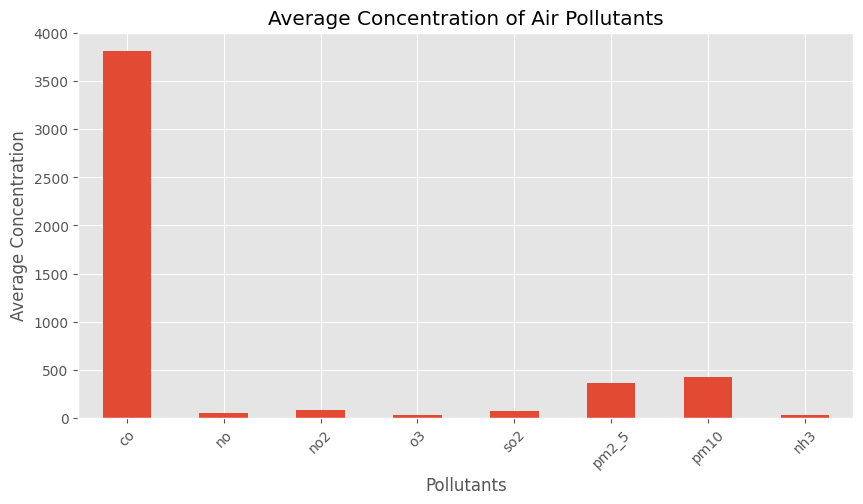

In [15]:
# Calculate the average concentration of each pollutant
average_pollutants = df.drop('date', axis=1).mean()

# Create the bar chart
plt.figure(figsize=(10,5))
average_pollutants.plot(kind='bar')

plt.title("Average Concentration of Air Pollutants")
plt.xlabel("Pollutants")
plt.ylabel("Average Concentration")
plt.xticks(rotation=45)

plt.show()

###Interpretation

The bar chart compares the average concentration of different air pollutants recorded in the dataset. It can be observed that Carbon Monoxide (CO) has the highest average concentration among all pollutants, followed by PM10 and PM2.5. On the other hand, Ozone (O₃) and Ammonia (NH₃) have comparatively lower average concentrations. This visualization provides a quick overview of the pollution levels and helps identify the pollutants that contribute most significantly to air pollution in the dataset.

### Distribution of PM2.5 Concentration

A histogram is used to understand the distribution of PM2.5 values in the dataset. It shows how frequently different concentration ranges occur, helping identify the spread of the data and the presence of any unusually high or low values.

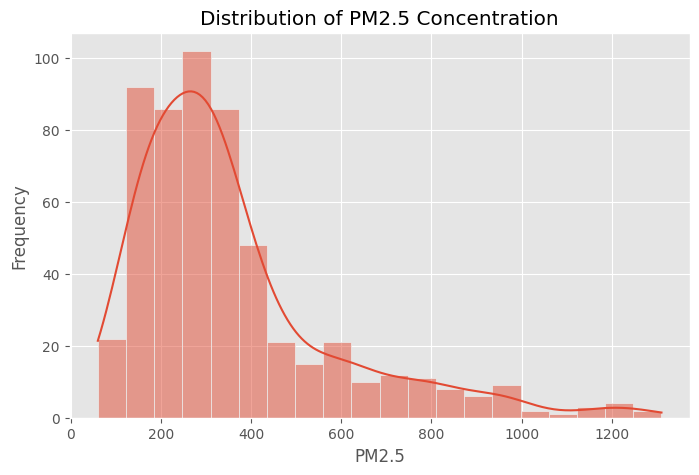

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['pm2_5'], bins=20, kde=True)

plt.title("Distribution of PM2.5 Concentration")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")

plt.show()

#### Interpretation

The histogram shows the distribution of PM2.5 concentration values in the dataset. Most observations are concentrated in the lower to middle concentration ranges, while fewer observations have very high PM2.5 values. The distribution is positively (right) skewed, indicating that although extremely high pollution levels occur less frequently, they are present in the dataset. The smooth KDE curve helps visualize the overall pattern of the distribution.

### Correlation Between Air Pollutants

A correlation heatmap is used to measure the relationship between different air pollutants. Correlation values range from -1 to +1, where values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values close to 0 indicate little or no relationship. This visualization helps identify pollutants that tend to increase or decrease together.

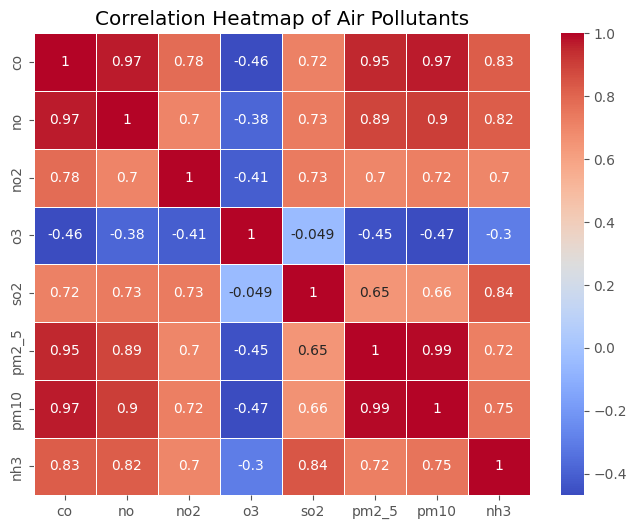

In [18]:
# Calculate correlation matrix
correlation = df.drop('date', axis=1).corr()

# Create heatmap
plt.figure(figsize=(8,6))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap of Air Pollutants")

plt.show()

#### Interpretation

The correlation heatmap illustrates the relationship between different air pollutants in the dataset. Darker colors and correlation values closer to 1 indicate a strong positive relationship, while values closer to 0 indicate a weak relationship. From the heatmap, it can be observed that PM2.5 and PM10 have a strong positive correlation, suggesting that they tend to increase and decrease together. Some other pollutants also show moderate positive relationships, whereas a few have weak correlations. This analysis helps in understanding how different pollutants are related and provides useful insights into air quality patterns.

### PM2.5 Trend Over Time

A line chart is used to visualize how PM2.5 concentration changes over time. This helps identify trends, fluctuations, and periods of high or low pollution levels throughout the dataset.

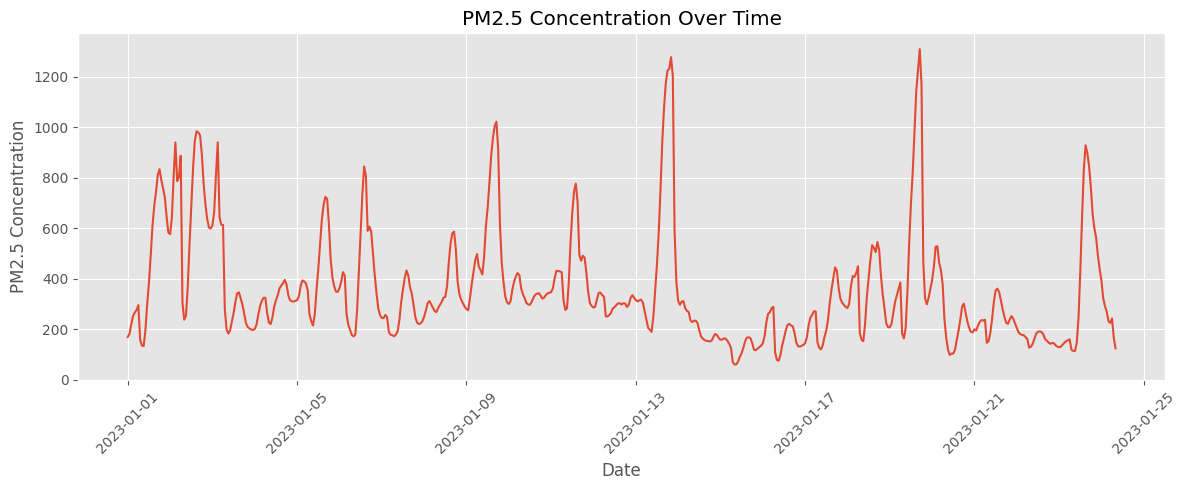

In [19]:
plt.figure(figsize=(12,5))

plt.plot(df['date'], df['pm2_5'])

plt.title("PM2.5 Concentration Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5 Concentration")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

#### Interpretation

The line chart illustrates how PM2.5 concentration changes over time in the dataset. The graph shows noticeable fluctuations in PM2.5 levels, indicating that air pollution is not constant and varies across different dates. Some periods show significantly higher PM2.5 concentrations, while others have comparatively lower values. This trend analysis helps identify changes in air quality over time and can be useful for monitoring pollution patterns and planning environmental measures.

### Distribution of Pollutants Using Box Plot

A box plot is used to visualize the spread of pollutant concentrations and identify the presence of outliers. It summarizes the distribution of the data using the minimum value, first quartile, median, third quartile, and maximum value.

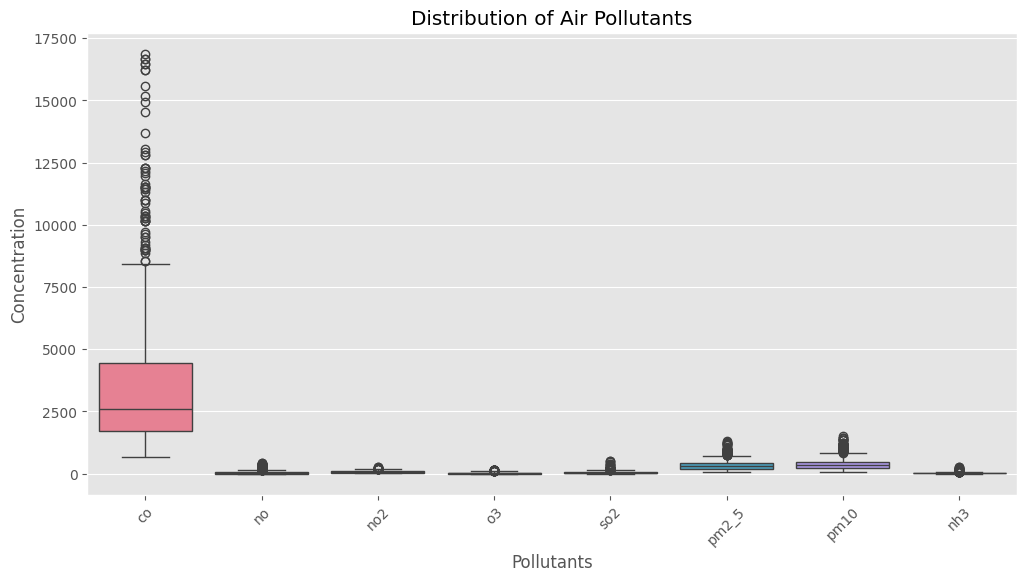

In [20]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df.drop('date', axis=1))

plt.title("Distribution of Air Pollutants")
plt.xlabel("Pollutants")
plt.ylabel("Concentration")

plt.xticks(rotation=45)

plt.show()

#### Interpretation

The box plot shows the distribution of concentration values for each air pollutant. It displays the median, spread of the data, and any potential outliers. Several pollutants, such as CO, PM2.5, PM10, and NH₃, show outliers, indicating that there are some observations with unusually high concentration levels. These outliers may represent periods of severe air pollution. Overall, the box plot helps us understand the variability of each pollutant and identify extreme values within the dataset.

### Relationship Between PM2.5 and PM10

A scatter plot is used to examine the relationship between PM2.5 and PM10 concentrations. Each point represents one observation in the dataset. This visualization helps determine whether the two pollutants increase or decrease together and provides a better understanding of their correlation.

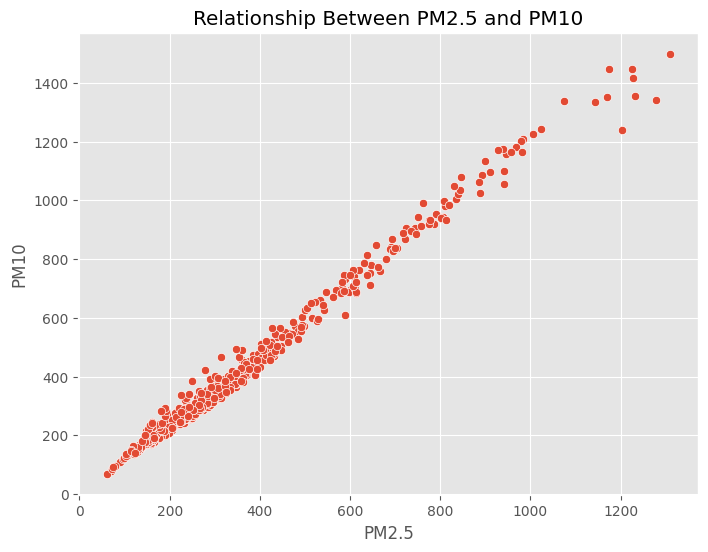

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='pm2_5', y='pm10', data=df)

plt.title("Relationship Between PM2.5 and PM10")
plt.xlabel("PM2.5")
plt.ylabel("PM10")

plt.show()

#### Interpretation

The scatter plot illustrates the relationship between PM2.5 and PM10 concentrations in the dataset. Most data points follow an upward trend, indicating a positive relationship between these two pollutants. This means that when PM2.5 concentration increases, PM10 concentration also tends to increase. The scatter plot supports the correlation analysis observed in the heatmap and confirms that these pollutants are closely related.

Key Findings

CO has the highest average concentration among the pollutants.
PM2.5 values are positively skewed.
PM2.5 and PM10 show a strong positive correlation.
Pollution levels fluctuate over time.
Outliers indicate occasional periods of very high pollution.

# Conclusion

This project analyzed Delhi's air quality data using Python and various data analysis libraries. The dataset was first examined and cleaned by verifying missing values, checking duplicate records, and converting the date column into the appropriate datetime format. After ensuring that the data was ready for analysis, several visualizations were created to explore pollution patterns.

The analysis revealed that Carbon Monoxide (CO), PM2.5, and PM10 had comparatively higher average concentrations than other pollutants. The histogram showed that PM2.5 values were positively skewed, indicating that extremely high pollution levels occurred less frequently but were present in the dataset. The correlation heatmap and scatter plot demonstrated a strong positive relationship between PM2.5 and PM10, suggesting that these pollutants tend to increase together. The line chart highlighted fluctuations in PM2.5 concentration over time, while the box plot identified several outliers, indicating occasional periods of unusually high pollution.

Overall, this project provided valuable insights into Delhi's air quality and demonstrated the importance of data cleaning, exploratory data analysis, and visualization in understanding environmental data. It also strengthened practical skills in Python, Pandas, Matplotlib, and Seaborn for data analysis.

# Future Scope

This project can be further improved by analyzing multiple years of air quality data, comparing pollution levels across different cities, developing interactive dashboards using Plotly or Power BI, and building machine learning models to predict future air pollution levels. Such improvements would provide deeper insights and support better environmental decision-making.

###Refrences

References

• Pandas Documentation: https://pandas.pydata.org/

• Matplotlib Documentation:
https://matplotlib.org/

• Seaborn Documentation:
https://seaborn.pydata.org/

• Delhi Air Quality Dataset